#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from matplotlib.patches import Patch

import warnings
warnings.filterwarnings('ignore')

import time

#### Import Datasets

In [2]:
%store -r Set1_X_Train
%store -r Set1_X_Test

%store -r Set1_y_Train
%store -r Set1_y_Test

#### Random Forest Regression(All Columns)

In [3]:
start = time.time()

Set1_y_Train_array = Set1_y_Train.values.ravel()
Set1_y_Test_array = Set1_y_Test.values.ravel()

'''
random_forest_reg = RandomForestRegressor(n_estimators=500,
                                          max_features='sqrt',
                                          n_jobs=-1,
                                          random_state=38
                                          ).fit(Set1_X_Train, Set1_y_Train_array)
'''

rf = RandomForestRegressor(n_jobs=-1, random_state=38)

param_grid = {
    "n_estimators": [50, 200, 300, 400, 500],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_root_mean_squared_error", 
                           n_jobs=-1, cv=5)

grid_search.fit(Set1_X_Train, Set1_y_Train_array)
end_grid_search = time.time()

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

random_forest_reg = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_features=best_params['max_features'],
                                n_jobs=-1,
                                random_state=38)

random_forest_reg.fit(Set1_X_Train, Set1_y_Train_array)
end_train = time.time()  

rf_reg_pred_train = random_forest_reg.predict(Set1_X_Train)
end_predict_train = time.time()

rf_reg_pred_test = random_forest_reg.predict(Set1_X_Test)
end_predict_test = time.time()

rf_reg_pred_train_int = rf_reg_pred_train.astype(int)
rf_reg_pred_test_int = rf_reg_pred_test.astype(int)

Best Parameters: {'max_features': 'sqrt', 'n_estimators': 500}


#### Random Forest Evaluation

In [4]:
# Mean Squared Error
mse_train_rf = mean_squared_error(Set1_y_Train_array, rf_reg_pred_train_int)
mse_test_rf = mean_squared_error(Set1_y_Test_array, rf_reg_pred_test_int)

# Root Mean Squared Error
rmse_train_rf = np.sqrt(mse_train_rf)
rmse_test_rf = np.sqrt(mse_test_rf)

# Mean Absolute Error
mae_train_rf = mean_absolute_error(Set1_y_Train_array, rf_reg_pred_train_int)
mae_test_rf = mean_absolute_error(Set1_y_Test_array, rf_reg_pred_test_int)

# R2 Score
r2_train_rf = r2_score(Set1_y_Train_array, rf_reg_pred_train_int)
r2_test_rf = r2_score(Set1_y_Test_array, rf_reg_pred_test_int)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf)
print("Root Mean Squared Error:", rmse_train_rf)
print("Mean Absolute Error:", mae_train_rf)
print("R-squared Score:", r2_train_rf)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf)
print("Root Mean Squared Error:", rmse_test_rf)
print("Mean Absolute Error:", mae_test_rf)
print("R-squared Score:", r2_test_rf)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 230.69613688139208
Root Mean Squared Error: 15.188684501344811
Mean Absolute Error: 10.665115602733751
R-squared Score: 0.9513746645846203

--Testing Set Evaluation--
Mean Squared Error: 1001.61
Root Mean Squared Error: 31.648222698913127
Mean Absolute Error: 22.83
R-squared Score: 0.41998515695684246

--Fit, Training Times--
Time for grid search: 67.39 seconds
Time to fit: 2.68 seconds
Time to predict (train set): 0.30 seconds
Time to predict (test set): 0.06 seconds
Total Time: 70.43 seconds


#### Plot Evaluation Results

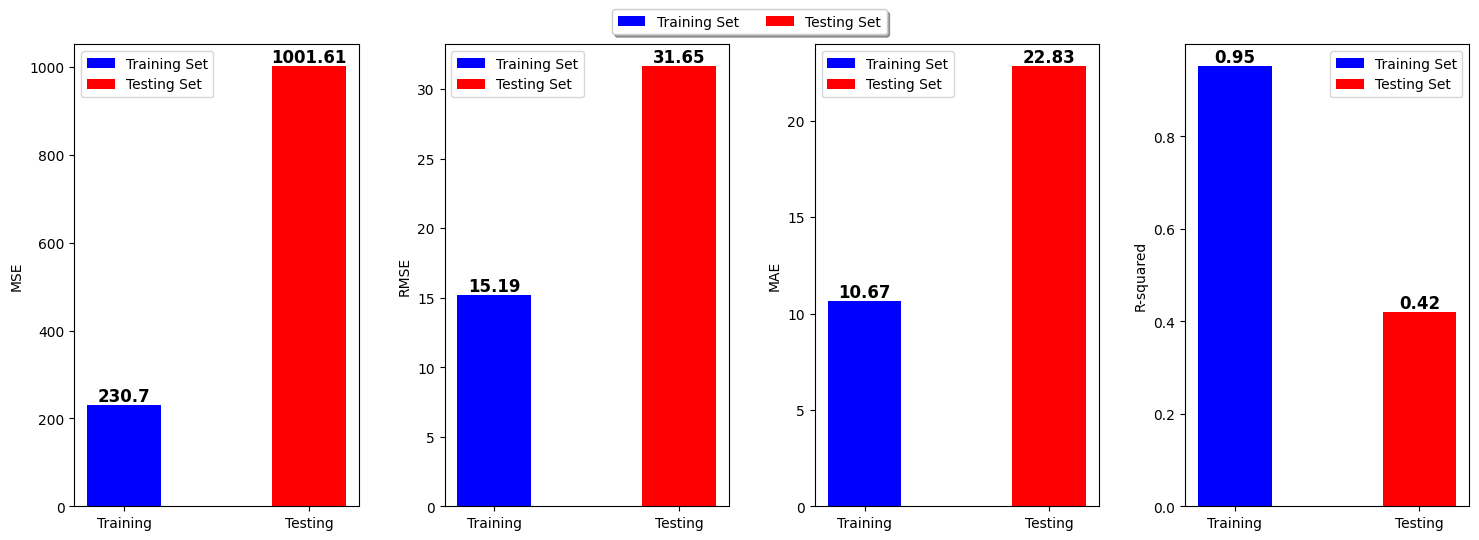

In [5]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared', 'COD']
train_metrics = [mse_train_rf, rmse_train_rf, mae_train_rf, r2_train_rf]
test_metrics = [mse_test_rf, rmse_test_rf, mae_test_rf, r2_test_rf]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

##### Plot Predicted vs Actual Values

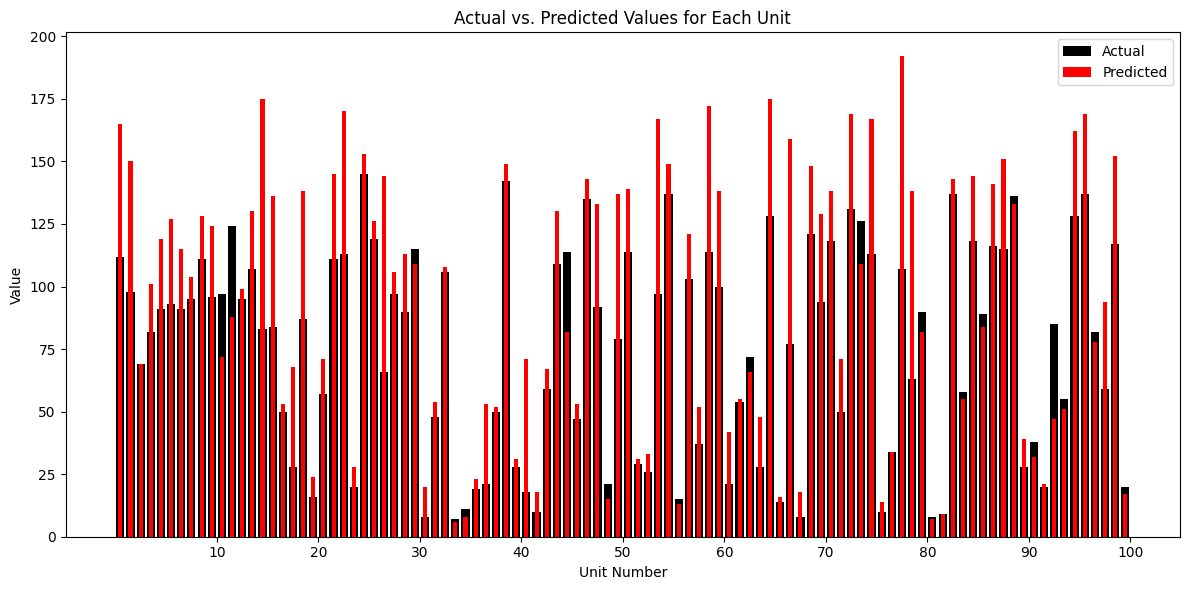

In [6]:
num_units = len(Set1_y_Test)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(Set1_y_Test)
predicted_values = np.squeeze(rf_reg_pred_test_int)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

#### Random Forest Regressor (Dropped Constant, Highly Related Features, Applied Upper RUL Limit)

##### Import Dataset

In [7]:
%store -r FD1_X_Train
%store -r FD1_X_Test

%store -r FD1_y_Train
%store -r FD1_y_Test

#### RF Regressor

In [8]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

'''
rf_new = RandomForestRegressor(n_estimators=500,
                              max_features='sqrt',
                              n_jobs=-1,
                              random_state=38
                             ).fit(FD1_X_Train,FD1_y_Train_array)

end_train = time.time()
'''

rf = RandomForestRegressor(n_jobs=-1, random_state=38)

param_grid = {
    "n_estimators": [50, 200, 300, 400, 500],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_root_mean_squared_error", 
                           n_jobs=-1, cv=5)

grid_search.fit(FD1_X_Train, FD1_y_Train_array)
end_grid_search = time.time()  

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

rf_new = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_features=best_params['max_features'],
                                n_jobs=-1,
                                random_state=38)

rf_new.fit(FD1_X_Train, FD1_y_Train_array)
end_train = time.time() 

rf_new_pred_train = rf_new.predict(FD1_X_Train)
end_predict_train = time.time()

rf_new_pred_test = rf_new.predict(FD1_X_Test)
end_predict_test = time.time()

Best Parameters: {'max_features': 'sqrt', 'n_estimators': 500}


#### Random Forest Evaluation

In [9]:
# Mean Squared Error
mse_train_rf_new = mean_squared_error(FD1_y_Train_array, rf_new_pred_train)
mse_test_rf_new = mean_squared_error(FD1_y_Test_array, rf_new_pred_test)

# Root Mean Squared Error
rmse_train_rf_new = np.sqrt(mse_train_rf_new)
rmse_test_rf_new = np.sqrt(mse_test_rf_new)

# Mean Absolute Error
mae_train_rf_new = mean_absolute_error(FD1_y_Train_array, rf_new_pred_train)
mae_test_rf_new = mean_absolute_error(FD1_y_Test_array, rf_new_pred_test)

# R2 Score
r2_train_rf_new = r2_score(FD1_y_Train_array, rf_new_pred_train)
r2_test_rf_new = r2_score(FD1_y_Test_array, rf_new_pred_test)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf_new)
print("Root Mean Squared Error:", rmse_train_rf_new)
print("Mean Absolute Error:", mae_train_rf_new)
print("R-squared Score:", r2_train_rf_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf_new)
print("Root Mean Squared Error:", rmse_test_rf_new)
print("Mean Absolute Error:", mae_test_rf_new)
print("R-squared Score:", r2_test_rf_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds\n")

%store mse_test_rf_new
%store rmse_test_rf_new
%store mae_test_rf_new
%store r2_test_rf_new

--Training Set Evaluation--
Mean Squared Error: 38.50847932858319
Root Mean Squared Error: 6.2055200691467585
Mean Absolute Error: 4.438354030342689
R-squared Score: 0.9795960111453391

--Testing Set Evaluation--
Mean Squared Error: 323.66355544
Root Mean Squared Error: 17.990651890356837
Mean Absolute Error: 13.54196
R-squared Score: 0.8125720926235542

--Fit, Training Times--
Time for grid search: 57.83 seconds
Time to fit: 2.45 seconds
Time to predict (train set): 0.20 seconds
Time to predict (test set): 0.07 seconds
Total Time: 60.54 seconds

Stored 'mse_test_rf_new' (float64)
Stored 'rmse_test_rf_new' (float64)
Stored 'mae_test_rf_new' (float64)
Stored 'r2_test_rf_new' (float64)


#### Plot Evaluation Metrics

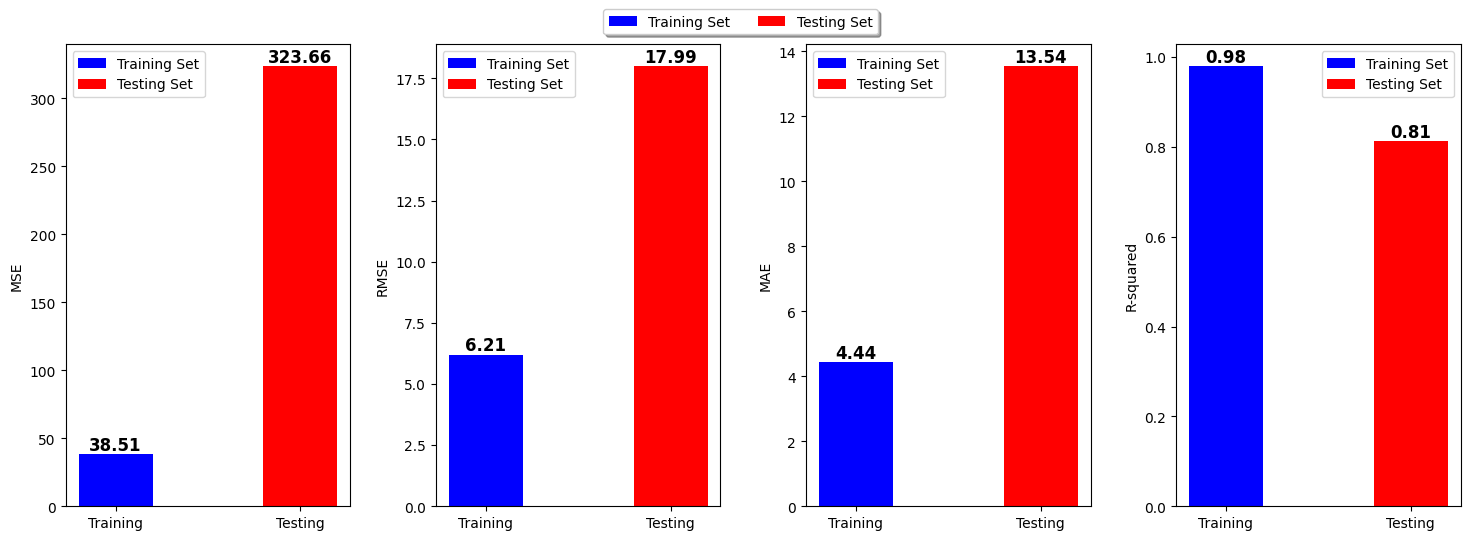

In [10]:
metrics = ['MSE', 'RMSE', 'MAE', 'R-squared']
train_metrics = [mse_train_rf_new, rmse_train_rf_new, mae_train_rf_new, r2_train_rf_new]
test_metrics = [mse_test_rf_new, rmse_test_rf_new, mae_test_rf_new, r2_test_rf_new]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for i, (metric, train_metric, test_metric) in enumerate(zip(metrics, train_metrics, test_metrics)):
    ax = axes[i]
    ax.bar('Training', train_metric, color='b', label='Training Set', width=0.4)
    ax.bar('Testing', test_metric, color='r', label='Testing Set', width=0.4)
    ax.set_ylabel(metric)

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, round(height, 2), 
                ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.legend()

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.95), fancybox=True, shadow=True, ncol=2)

plt.subplots_adjust(wspace=0.3)
plt.show()

#### Plot Actual vs Predicted Values

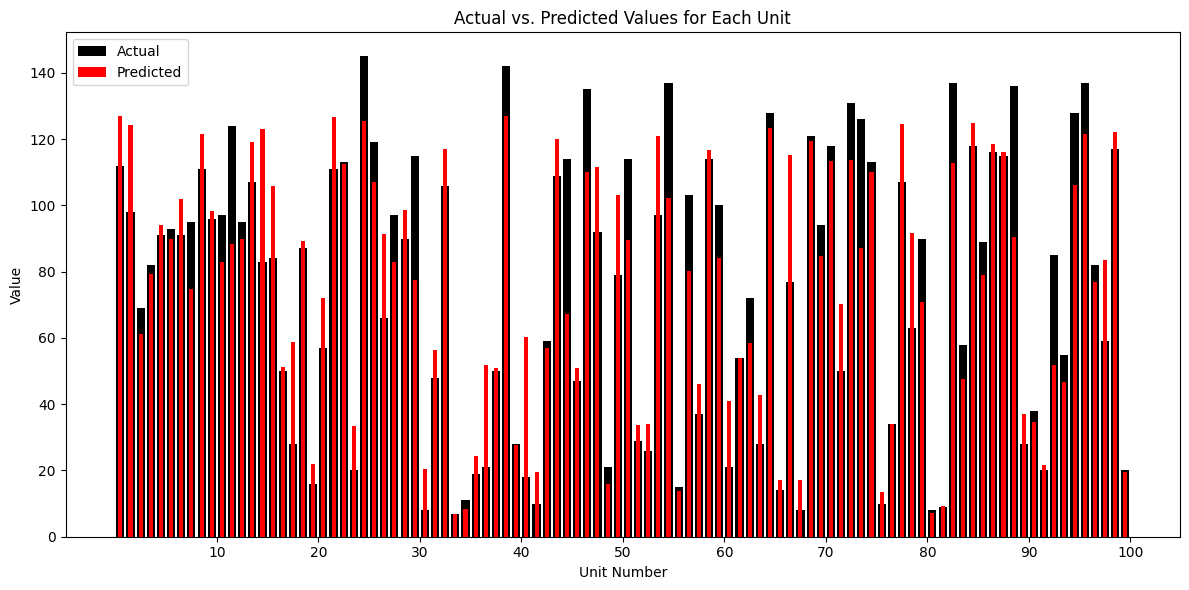

In [11]:
num_units = len(FD1_y_Test_array)
unit_numbers = np.arange(1, num_units + 1) 

actual_values = np.squeeze(FD1_y_Test_array)
predicted_values = np.squeeze(rf_new_pred_test)

fig, ax = plt.subplots(figsize=(12, 6))

bar_width = 0.8
spacing = 1

ax.bar(unit_numbers - spacing/2, actual_values, bar_width, label='Actual', color='black')
ax.bar(unit_numbers - spacing/2, predicted_values, bar_width/2, label='Predicted', color='red')

ax.set_xlabel('Unit Number')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for Each Unit')

tick_positions = np.arange(10, num_units + 1, 10)
ax.set_xticks(tick_positions)
ax.set_xticklabels([str(int(t)) for t in tick_positions]) 

ax.legend()
plt.tight_layout()
plt.show()

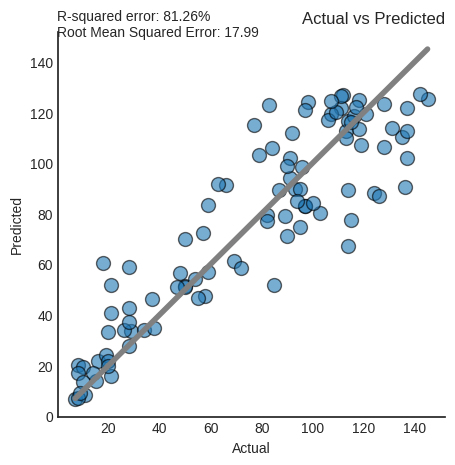

In [12]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 

fig,ax = plt.subplots()
plt.title('Actual vs Predicted', loc='right')
plt.xlabel('Actual')
plt.ylabel('Predicted')
g = sns.scatterplot(x=FD1_y_Test_array,
                y=rf_new_pred_test,
                s=100,
                alpha=0.6,
                linewidth=1,
                edgecolor='black',
                ax=ax)
f = sns.lineplot(x=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             y=[min(FD1_y_Test_array),max(FD1_y_Test_array)],
             linewidth=4,
             color='gray',
             ax=ax)

plt.annotate(text=('R-squared error: '+ "{:.2%}".format(rf_new.score(FD1_X_Test,FD1_y_Test_array)) +'\n' +
                  'Root Mean Squared Error: '+ "{:.2f}".format(mean_squared_error(FD1_y_Test_array,rf_new_pred_test,squared=False))),
             xy=(0,150),
             size='medium')

xlabels = ['{:,.0f}'.format(x) for x in g.get_xticks()]
g.set_xticklabels(xlabels)
ylabels = ['{:,.0f}'.format(x) for x in g.get_yticks()]
g.set_yticklabels(ylabels)
sns.despine()

#### Performance in each subset of [0, 20], [21, 50], [51, 90], [91, 145]

In [13]:
High_Risk = (0, 20)
Mid_Risk = (21, 50)
Low_Risk = (51, 90)
Healthy = (91, 200)

subset_1 = {}
subset_2 = {}
subset_3 = {}
subset_4 = {}

subset_1_indices = np.where((FD1_y_Test_array >= High_Risk[0]) & (FD1_y_Test_array <= High_Risk[1]))[0]
subset_1['RUL'] = FD1_y_Test_array[subset_1_indices]
subset_1['unit_number'] = subset_1_indices

subset_2_indices = np.where((FD1_y_Test_array >= Mid_Risk[0]) & (FD1_y_Test_array <= Mid_Risk[1]))[0]
subset_2['RUL'] = FD1_y_Test_array[subset_2_indices]
subset_2['unit_number'] = subset_2_indices

subset_3_indices = np.where((FD1_y_Test_array >= Low_Risk[0]) & (FD1_y_Test_array <= Low_Risk[1]))[0]
subset_3['RUL'] = FD1_y_Test_array[subset_3_indices]
subset_3['unit_number'] = subset_3_indices

subset_4_indices = np.where((FD1_y_Test_array >= Healthy[0]) & (FD1_y_Test_array <= Healthy[1]))[0]
subset_4['RUL'] = FD1_y_Test_array[subset_4_indices]
subset_4['unit_number'] = subset_4_indices

y_Test_subset_1 = pd.DataFrame(subset_1)['RUL']
y_Test_subset_2 = pd.DataFrame(subset_2)['RUL']
y_Test_subset_3 = pd.DataFrame(subset_3)['RUL']
y_Test_subset_4 = pd.DataFrame(subset_4)['RUL']

rf_subset1_pred = rf_new_pred_test[subset_1_indices]
rf_subset2_pred = rf_new_pred_test[subset_2_indices]
rf_subset3_pred = rf_new_pred_test[subset_3_indices]
rf_subset4_pred = rf_new_pred_test[subset_4_indices]

# Print the lengths of predictions to verify
print("Predictions for Subset 1 (RUL range [0, ]):", len(rf_subset1_pred))
print("Predictions for Subset 2 (RUL range [, ]):", len(rf_subset2_pred))
print("Predictions for Subset 3 (RUL range [, ]):", len(rf_subset3_pred))
print("Predictions for Subset 4 (RUL range [, 200]):", len(rf_subset4_pred))

Predictions for Subset 1 (RUL range [0, ]): 16
Predictions for Subset 2 (RUL range [, ]): 17
Predictions for Subset 3 (RUL range [, ]): 21
Predictions for Subset 4 (RUL range [, 200]): 46


In [14]:
# Mean Squared Error
mse_test_rf_sub1 = mean_squared_error(y_Test_subset_1, rf_subset1_pred)
mse_test_rf_sub2 = mean_squared_error(y_Test_subset_2, rf_subset2_pred)
mse_test_rf_sub3 = mean_squared_error(y_Test_subset_3, rf_subset3_pred)
mse_test_rf_sub4 = mean_squared_error(y_Test_subset_4, rf_subset4_pred)

# Root Mean Squared Error
rmse_test_rf_sub1 = np.sqrt(mse_test_rf_sub1)
rmse_test_rf_sub2 = np.sqrt(mse_test_rf_sub2)
rmse_test_rf_sub3 = np.sqrt(mse_test_rf_sub3)
rmse_test_rf_sub4 = np.sqrt(mse_test_rf_sub4)

# Mean Absolute Error
mae_test_rf_sub1 = mean_absolute_error(y_Test_subset_1, rf_subset1_pred)
mae_test_rf_sub2 = mean_absolute_error(y_Test_subset_2, rf_subset2_pred)
mae_test_rf_sub3 = mean_absolute_error(y_Test_subset_3, rf_subset3_pred)
mae_test_rf_sub4 = mean_absolute_error(y_Test_subset_4, rf_subset4_pred)

# Testing Set
print("\n--Units at High Risk--")
print("Mean Squared Error:", mse_test_rf_sub1)
print("Root Mean Squared Error:", rmse_test_rf_sub1)
print("Mean Absolute Error:", mae_test_rf_sub1)
print("\n--Units at Mid Risk--")
print("Mean Squared Error:", mse_test_rf_sub2)
print("Root Mean Squared Error:", rmse_test_rf_sub2)
print("Mean Absolute Error:", mae_test_rf_sub2)
print("\n--Units at Low Risk--")
print("Mean Squared Error:", mse_test_rf_sub3)
print("Root Mean Squared Error:", rmse_test_rf_sub3)
print("Mean Absolute Error:", mae_test_rf_sub3)
print("\n--Healthy Units--")
print("Mean Squared Error:", mse_test_rf_sub4)
print("Root Mean Squared Error:", rmse_test_rf_sub4)
print("Mean Absolute Error:", mae_test_rf_sub4)


--Units at High Risk--
Mean Squared Error: 149.63191225
Root Mean Squared Error: 12.232412364288574
Mean Absolute Error: 6.977875000000001

--Units at Mid Risk--
Mean Squared Error: 194.86295552941178
Root Mean Squared Error: 13.959332202129577
Mean Absolute Error: 10.06670588235294

--Units at Low Risk--
Mean Squared Error: 405.8478470476191
Root Mean Squared Error: 20.14566571368688
Mean Absolute Error: 16.258380952380953

--Healthy Units--
Mean Squared Error: 394.2776068695653
Root Mean Squared Error: 19.85642482597422
Mean Absolute Error: 15.86934782608696


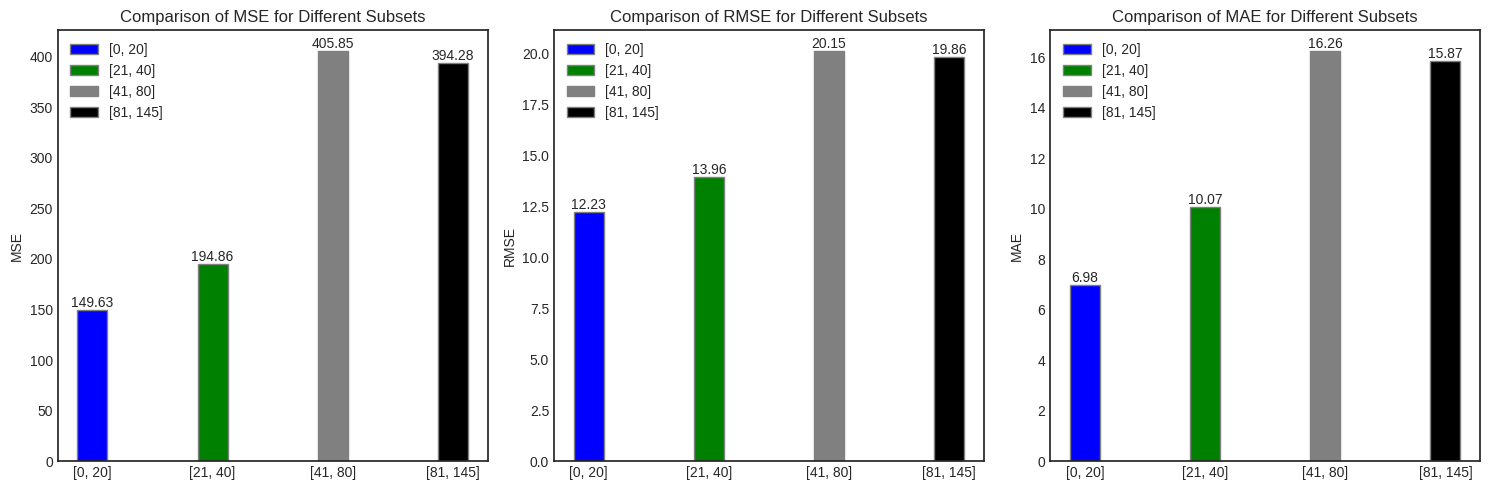

In [15]:
mse_values = [mse_test_rf_sub1, mse_test_rf_sub2, mse_test_rf_sub3, mse_test_rf_sub4]
rmse_values = [rmse_test_rf_sub1, rmse_test_rf_sub2, rmse_test_rf_sub3, rmse_test_rf_sub4]
mae_values = [mae_test_rf_sub1, mae_test_rf_sub2, mae_test_rf_sub3, mae_test_rf_sub4]

subset_labels = ['[0, 20]', '[21, 40]', '[41, 80]', '[81, 145]']
bar_width = 0.25

r1 = np.arange(len(subset_labels))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Plot MSE
mse_bars = ax1.bar(r1, mse_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in mse_bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax1.set_ylabel('MSE')
ax1.set_title('Comparison of MSE for Different Subsets')
ax1.set_xticks(r1)
ax1.set_xticklabels(subset_labels)

# Plot RMSE
rmse_bars = ax2.bar(r1, rmse_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in rmse_bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax2.set_ylabel('RMSE')
ax2.set_title('Comparison of RMSE for Different Subsets')
ax2.set_xticks(r1)
ax2.set_xticklabels(subset_labels)

# Plot MAE
mae_bars = ax3.bar(r1, mae_values, color=['blue', 'green', 'grey', 'black'], width=bar_width, edgecolor='grey')
for bar in mae_bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, height, '%.2f' % height, ha='center', va='bottom')
ax3.set_ylabel('MAE')
ax3.set_title('Comparison of MAE for Different Subsets')
ax3.set_xticks(r1)
ax3.set_xticklabels(subset_labels)

legend_handles = [Patch(facecolor=color, edgecolor='grey', label=label) for color, label in zip(['blue', 'green', 'grey', 'black'], subset_labels)]

ax1.legend(handles=legend_handles, loc='upper left')
ax2.legend(handles=legend_handles, loc='upper left')
ax3.legend(handles=legend_handles, loc='upper left')

plt.tight_layout()
plt.show()

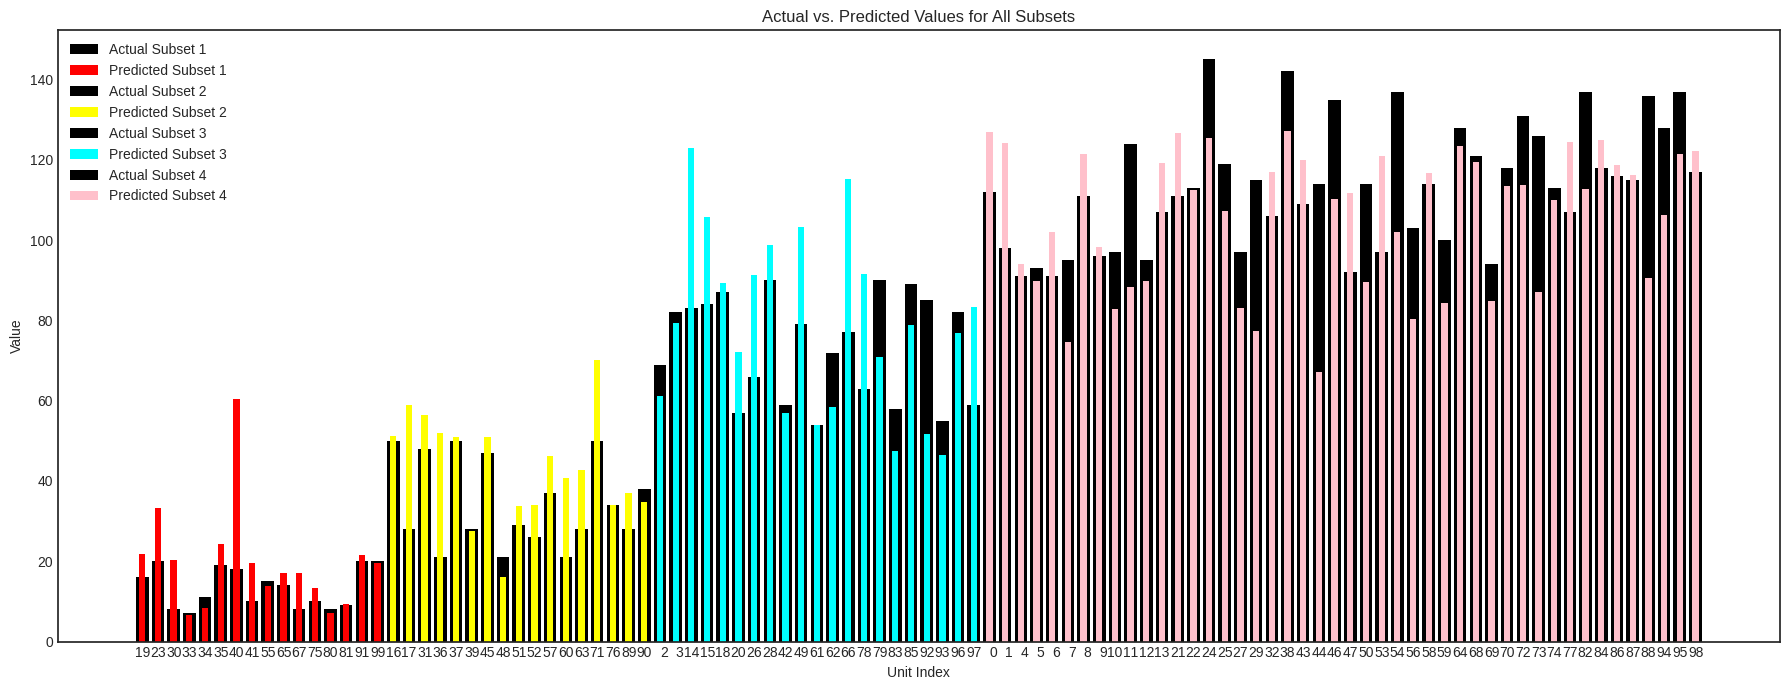

In [16]:
spacing = 1
actual_bar_width = 0.8
predicted_bar_width = 0.4

fig, ax = plt.subplots(figsize=(18, 7))

subset_1_tick_positions = np.linspace(0, len(subset_1_indices) - 1, num=len(subset_1_indices))
ax.bar(subset_1_tick_positions - spacing/2, subset_1['RUL'], actual_bar_width, label='Actual Subset 1', color='black')
ax.bar(subset_1_tick_positions - spacing/2, rf_subset1_pred, predicted_bar_width, label='Predicted Subset 1', color='red')

subset_2_tick_positions = subset_1_tick_positions[-1] + np.linspace(1, len(subset_2_indices), num=len(subset_2_indices))
ax.bar(subset_2_tick_positions - spacing/2, subset_2['RUL'], actual_bar_width, label='Actual Subset 2', color='black')
ax.bar(subset_2_tick_positions - spacing/2, rf_subset2_pred, predicted_bar_width, label='Predicted Subset 2', color='yellow')

subset_3_tick_positions = subset_2_tick_positions[-1] + np.linspace(1, len(subset_3_indices), num=len(subset_3_indices))
ax.bar(subset_3_tick_positions - spacing/2, subset_3['RUL'], actual_bar_width, label='Actual Subset 3', color='black')
ax.bar(subset_3_tick_positions - spacing/2, rf_subset3_pred, predicted_bar_width, label='Predicted Subset 3', color='cyan')

subset_4_tick_positions = subset_3_tick_positions[-1] + np.linspace(1, len(subset_4_indices), num=len(subset_4_indices))
ax.bar(subset_4_tick_positions - spacing/2, subset_4['RUL'], actual_bar_width, label='Actual Subset 4', color='black')
ax.bar(subset_4_tick_positions - spacing/2, rf_subset4_pred, predicted_bar_width, label='Predicted Subset 4', color='pink')

ax.set_xlabel('Unit Index')
ax.set_ylabel('Value')
ax.set_title('Actual vs. Predicted Values for All Subsets')

all_tick_positions = np.concatenate([subset_1_tick_positions, subset_2_tick_positions, subset_3_tick_positions, subset_4_tick_positions])
all_tick_labels = np.concatenate([subset_1_indices, subset_2_indices, subset_3_indices, subset_4_indices])
ax.set_xticks(all_tick_positions)
ax.set_xticklabels(all_tick_labels, ha='right')

ax.legend()
plt.tight_layout()
plt.show()

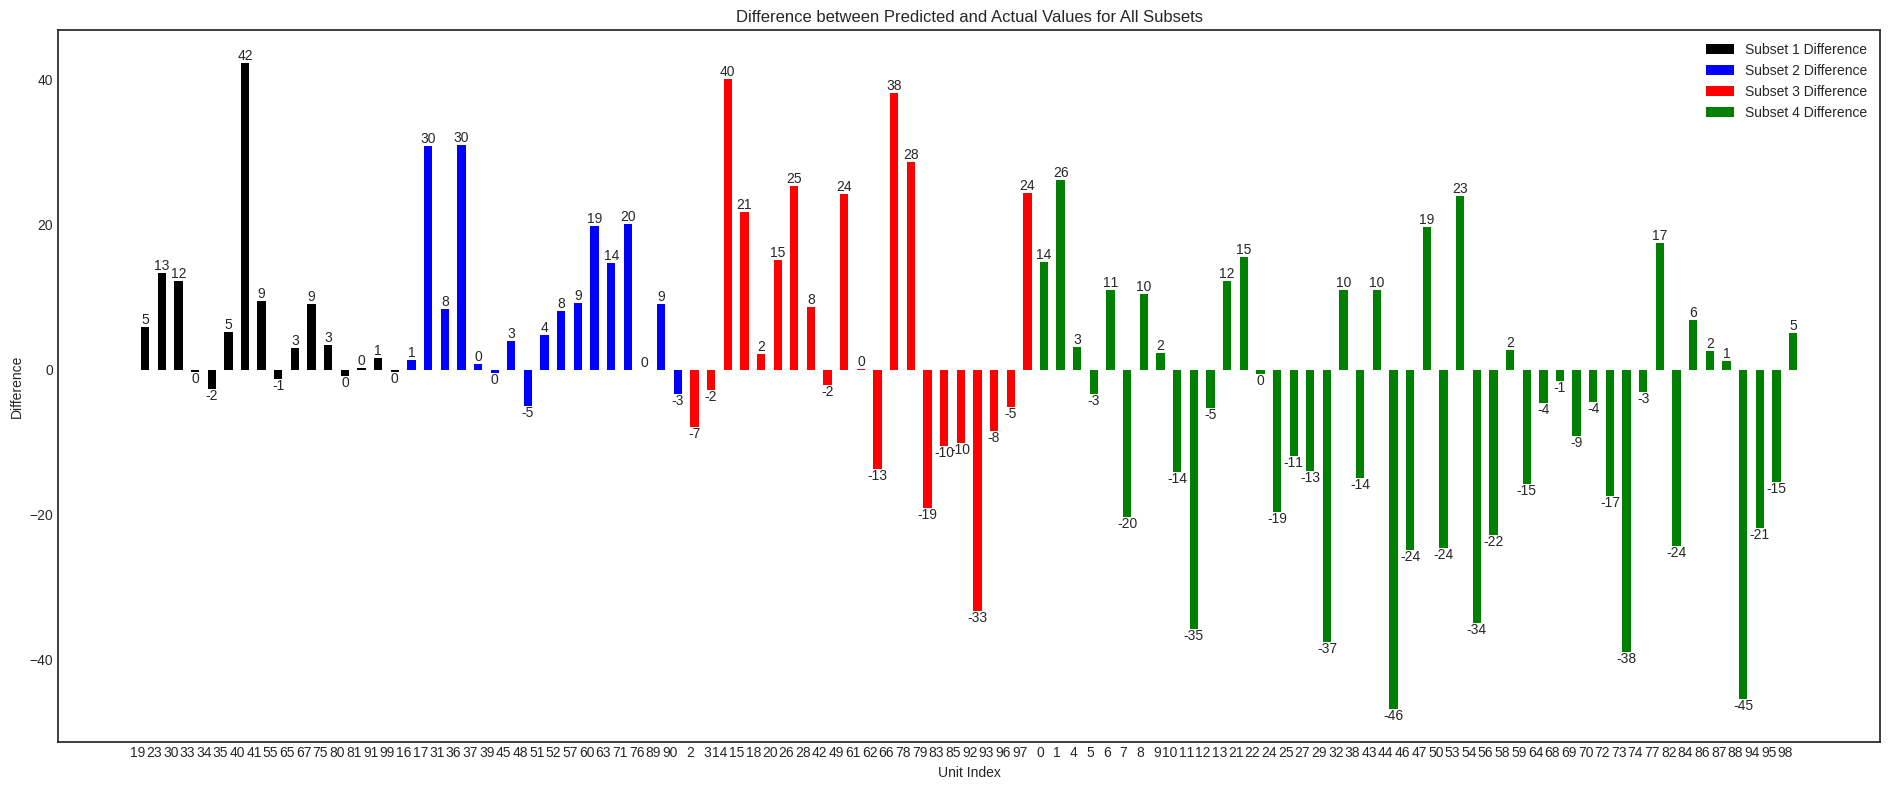

In [17]:
diff_subset1 = rf_subset1_pred - subset_1['RUL']
diff_subset2 = rf_subset2_pred - subset_2['RUL']
diff_subset3 = rf_subset3_pred - subset_3['RUL']
diff_subset4 = rf_subset4_pred - subset_4['RUL']

fig, ax = plt.subplots(figsize=(19, 8))

bar_width = 0.5

subset_1_bar_positions = np.linspace(0, len(subset_1_indices) - 1, num=len(subset_1_indices))
bars1 = ax.bar(subset_1_bar_positions, diff_subset1, bar_width, label='Subset 1 Difference', color='black')

subset_2_bar_positions = np.linspace(0, len(subset_2_indices) - 1, num=len(subset_2_indices)) + len(subset_1_indices)
bars2 = ax.bar(subset_2_bar_positions, diff_subset2, bar_width, label='Subset 2 Difference', color='blue')

subset_3_bar_positions = np.linspace(0, len(subset_3_indices) - 1, num=len(subset_3_indices)) + len(subset_1_indices) + len(subset_2_indices)
bars3 = ax.bar(subset_3_bar_positions, diff_subset3, bar_width, label='Subset 3 Difference', color='red')

subset_4_bar_positions = np.linspace(0, len(subset_4_indices) - 1, num=len(subset_4_indices)) + len(subset_1_indices) + len(subset_2_indices) + len(subset_3_indices)
bars4 = ax.bar(subset_4_bar_positions, diff_subset4, bar_width, label='Subset 4 Difference', color='green')

for bars, diffs in zip([bars1, bars2, bars3, bars4], [diff_subset1, diff_subset2, diff_subset3, diff_subset4]):
    for bar, diff in zip(bars, diffs):
        va = 'top' if diff < 0 else 'bottom'
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(diff)}', ha='center', va=va)

ax.set_xlabel('Unit Index')
ax.set_ylabel('Difference')
ax.set_title('Difference between Predicted and Actual Values for All Subsets')

all_bar_positions = np.concatenate([subset_1_bar_positions, subset_2_bar_positions, subset_3_bar_positions, subset_4_bar_positions])
all_tick_labels = np.concatenate([subset_1_indices, subset_2_indices, subset_3_indices, subset_4_indices])
ax.set_xticks(all_bar_positions)
ax.set_xticklabels(all_tick_labels, ha='right')

ax.legend()
plt.tight_layout()
plt.show()

##### Last 5 Cycles from X_Test

In [18]:
%store -r Last_5_X_Test

In [19]:
start = time.time()

FD1_y_Train_array = FD1_y_Train.values.ravel()
FD1_y_Test_array = FD1_y_Test.values.ravel()

'''
rf_new = RandomForestRegressor(n_estimators=500,
                              max_features='sqrt',
                              n_jobs=-1,
                              random_state=38
                             ).fit(FD1_X_Train,FD1_y_Train_array)

end_train = time.time()
'''

rf = RandomForestRegressor(n_jobs=-1, random_state=38)

param_grid = {
    "n_estimators": [50, 200, 300, 400, 500],
    "max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring="neg_root_mean_squared_error", 
                           n_jobs=-1, cv=5)

grid_search.fit(FD1_X_Train, FD1_y_Train_array)
end_grid_search = time.time()  

best_params = grid_search.best_params_
print("Best Parameters:", best_params)

rf_new = RandomForestRegressor(n_estimators=best_params['n_estimators'],
                                max_features=best_params['max_features'],
                                n_jobs=-1,
                                random_state=38)

rf_new.fit(FD1_X_Train, FD1_y_Train_array)
end_train = time.time() 

rf_new_pred_train = rf_new.predict(FD1_X_Train)
end_predict_train = time.time()

rf_new_pred_test = rf_new.predict(Last_5_X_Test)
end_predict_test = time.time()

Best Parameters: {'max_features': 'sqrt', 'n_estimators': 500}


In [20]:
rf_new_pred_test_reshaped = rf_new_pred_test.reshape(-1, 5)
average_rul_per_group = np.mean(rf_new_pred_test_reshaped, axis=1)

In [21]:
# Mean Squared Error
mse_train_rf_new = mean_squared_error(FD1_y_Train_array, rf_new_pred_train)
mse_test_rf_new = mean_squared_error(FD1_y_Test_array, average_rul_per_group)

# Root Mean Squared Error
rmse_train_rf_new = np.sqrt(mse_train_rf_new)
rmse_test_rf_new = np.sqrt(mse_test_rf_new)

# Mean Absolute Error
mae_train_rf_new = mean_absolute_error(FD1_y_Train_array, rf_new_pred_train)
mae_test_rf_new = mean_absolute_error(FD1_y_Test_array, average_rul_per_group)

# R2 Score
r2_train_rf_new = r2_score(FD1_y_Train_array, rf_new_pred_train)
r2_test_rf_new = r2_score(FD1_y_Test_array, average_rul_per_group)

# Time
time_grid_search = end_grid_search - start
fit_time = end_train - end_grid_search
time_predict_train = end_predict_train - end_train
time_predict_test = end_predict_test - end_predict_train
total_time = end_predict_test - start

# Training Set
print("--Training Set Evaluation--")
print("Mean Squared Error:", mse_train_rf_new)
print("Root Mean Squared Error:", rmse_train_rf_new)
print("Mean Absolute Error:", mae_train_rf_new)
print("R-squared Score:", r2_train_rf_new)

# Testing Set
print("\n--Testing Set Evaluation--")
print("Mean Squared Error:", mse_test_rf_new)
print("Root Mean Squared Error:", rmse_test_rf_new)
print("Mean Absolute Error:", mae_test_rf_new)
print("R-squared Score:", r2_test_rf_new)

# Time
print("\n--Fit, Training Times--")
print("Time for grid search:", "{:.2f}".format(time_grid_search), "seconds")
print("Time to fit:", "{:.2f}".format(fit_time), "seconds")
print("Time to predict (train set):", "{:.2f}".format(time_predict_train), "seconds")
print("Time to predict (test set):", "{:.2f}".format(time_predict_test), "seconds")
print("Total Time:", "{:.2f}".format(total_time), "seconds")

--Training Set Evaluation--
Mean Squared Error: 38.50847932858319
Root Mean Squared Error: 6.2055200691467585
Mean Absolute Error: 4.438354030342689
R-squared Score: 0.9795960111453391

--Testing Set Evaluation--
Mean Squared Error: 354.2481619808
Root Mean Squared Error: 18.821481397084554
Mean Absolute Error: 14.323248000000001
R-squared Score: 0.7948610815890209

--Fit, Training Times--
Time for grid search: 58.06 seconds
Time to fit: 2.50 seconds
Time to predict (train set): 0.21 seconds
Time to predict (test set): 0.06 seconds
Total Time: 60.82 seconds
